# Labwork 4

In [176]:
from matplotlib import pyplot as plt
from matplotlib import image
from time import time

from PIL import Image
import numpy as np
if not hasattr(np, 'row_stack'):
        np.row_stack = np.vstack
        
from numba import config
# Direct Numba's JIT infrastructure to safely link against the driver 
config.CUDA_ENABLE_MINOR_VERSION_COMPATIBILITY = 1
config.CUDA_LOW_OCCUPANCY_WARNINGS = 0

from numba import cuda
from numba import config

# img = image.imread("cat.jpg")
img = np.array(Image.open("wallhaven-2.png"))

print (img.shape)
pixelCount = img.shape[0] * img.shape[1]
img_flat = img.reshape(pixelCount, 4)


(2160, 3840, 4)


In [177]:
def save_log(device,  time, blockSize, blockSize_desp):
    with open("log.csv", "a") as f:
        f.write(f"{time},{device},{blockSize},{blockSize_desp}\n")

In [178]:
# Grayscale conversion using GPU
@cuda.jit
def grayscale_gpu(src, dst) -> None:

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x # type: ignore
    g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2] + src[tidx, 3]) / 4)
    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


In [179]:
blockSizeValues = [16, 32, 64, 128, 256, 512, 1024]

devInput = cuda.to_device(img_flat)
devOutput = cuda.device_array((pixelCount, 3), dtype=np.uint8)
blockSize = 64
gridSize = pixelCount // blockSize
grayscale_gpu[gridSize, blockSize](devInput, devOutput)
hostOutput = devOutput.copy_to_host()

for blockSize in blockSizeValues:
    cuda.synchronize()
    gridSize = pixelCount // blockSize
    t0 = time()
    devInput = cuda.to_device(img_flat)
    devOutput = cuda.device_array((pixelCount, 3), dtype=np.uint8)
    grayscale_gpu[gridSize, blockSize](devInput, devOutput)
    hostOutput = devOutput.copy_to_host()

    print(f"GPU time: {(time() - t0)*1000} ms")
    save_log("1D", (time() - t0) * 1000, blockSize, blockSize)

    # # Display the grayscale image
    # plt.imshow(hostOutput.reshape(img.shape[0], img.shape[1], 3))
    # plt.savefig(f"wall_1d_{blockSize}.jpg")
    # plt.show()

GPU time: 13.183832168579102 ms
GPU time: 12.056350708007812 ms
GPU time: 11.34634017944336 ms
GPU time: 12.009143829345703 ms
GPU time: 12.620925903320312 ms
GPU time: 15.536308288574219 ms
GPU time: 12.417793273925781 ms


In [180]:
# 2D
@cuda.jit
def grayscale_gpu_2d(src, dst) -> None:

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y 
    g = np.uint8(
        (src[tidx, tidy, 0] + src[tidx, tidy, 1] + src[tidx, tidy, 2] + src[tidx, tidy, 3]) / 4)
    dst[tidx, tidy, 0] = dst[tidx, tidy, 1] = dst[tidx, tidy, 2] = dst[tidx, tidy, 3] = g

In [181]:
# different block size
blockSizeValues = [(4,4), (4,8), (8,4), (8,8), (16,16), (32,32)]
devInput = cuda.to_device(img)
devOutput = cuda.device_array(img.shape, dtype=np.uint8)
blockSize = (8, 8)
gridSize = (img.shape[0]//blockSize[0], img.shape[1]//blockSize[1])


grayscale_gpu_2d[gridSize, blockSize](devInput, devOutput)
hostOutput = devOutput.copy_to_host()

for blockSize in blockSizeValues:
    cuda.synchronize()
    gridSize = (img.shape[0]//blockSize[0], img.shape[1]//blockSize[1])
    t0 = time()
    devInput = cuda.to_device(img)
    devOutput = cuda.device_array(img.shape, dtype=np.uint8)
    grayscale_gpu_2d[gridSize, blockSize](devInput, devOutput)
    hostOutput = devOutput.copy_to_host()

    print(f"GPU time: {(time() - t0)*1000} ms")
    save_log("2D",  (time() - t0) * 1000,f"{blockSize[0]*blockSize[1]}",f"{blockSize[0]}:{blockSize[1]}")

    # # Display the grayscale image
    # plt.imshow(hostOutput)
    # plt.savefig(f"wall_2d_{blockSize[0]*blockSize[1]}.jpg")
    # plt.show()

GPU time: 18.332958221435547 ms
GPU time: 16.022920608520508 ms
GPU time: 17.863988876342773 ms
GPU time: 15.34581184387207 ms
GPU time: 18.240690231323242 ms
GPU time: 24.54996109008789 ms


   dim  blockSize blockSize-desp  time (ms)
0   1D         16             16  14.746348
1   1D         32             32  14.259974
2   1D         64             64  14.086485
3   1D        128            128  15.109142
4   1D        256            256  13.523181
5   1D        512            512  14.743487
6   1D       1024           1024  13.615052
7   2D         16            4:4  19.472996
8   2D         32            4:8  15.996615
9   2D         32            8:4  17.481089
10  2D         64            8:8  15.148799
11  2D        256          16:16  18.418550
12  2D       1024          32:32  24.587472


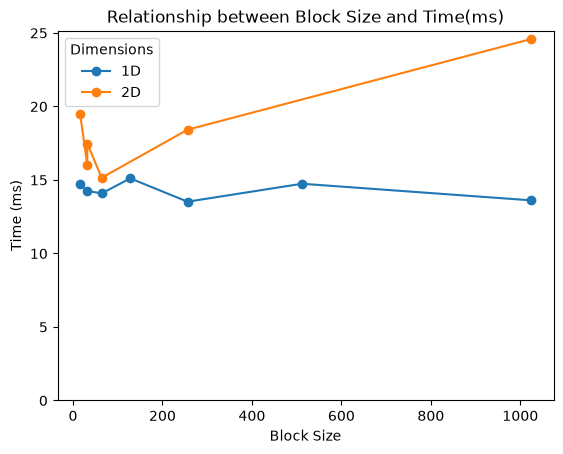

In [182]:
# blocksize vs speedup
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv("log.csv", header=None, names=["time (ms)", "dim", "blockSize", "blockSize-desp"])
# df = df[df["blockSize"] != 16]
mean_df = df.groupby(["dim", "blockSize", "blockSize-desp"]).mean().reset_index()
print(mean_df)
fix, ax = plt.subplots()

for dim_name, each_dim in mean_df.groupby("dim"):
    ax.plot(each_dim["blockSize"], each_dim["time (ms)"], label=dim_name, marker="o")

ax.set_ylim(bottom=0)
ax.set_xlabel("Block Size")
ax.set_ylabel("Time (ms)")
ax.set_title("Relationship between Block Size and Time(ms)")

ax.legend(title="Dimensions")

plt.savefig("relationship.jpg", bbox_inches="tight")
plt.show()
